# 03 — Algoritmos Genéticos

**Curso:** Inteligencia Artificial — Optimización

Este notebook contiene ejemplos guiados y actividades para desarrollar en clase.

## Objetivos

- representar soluciones mediante cromosomas;
- implementar selección, cruce y mutación;
- observar la evolución de una población;
- analizar el balance entre exploración y explotación.

![HillClimbing](https://drive.google.com/uc?export=view&id=1XSZ2ppaVR85ZRJErD0-0tB4aP26ReY5H)

## 1. Problema OneMax

Cada individuo es una cadena binaria de longitud $L$. Queremos maximizar el número de unos:

$$
\text{fitness}(x)=\sum_{i=1}^{L}x_i
$$

El óptimo global es una cadena formada completamente por unos. Es un problema sencillo, pero permite observar con claridad todos los componentes de un algoritmo genético.

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 14
random.seed(SEED)
np.random.seed(SEED)


def create_individual(length, rng):
    return [rng.randint(0, 1) for _ in range(length)]


def fitness(individual):
    return sum(individual)


def as_string(individual):
    return ''.join(map(str, individual))

rng = random.Random(SEED)
example = create_individual(20, rng)
print(as_string(example), 'fitness =', fitness(example))

00111011111010111100 fitness = 13


## 2. Selección por torneo

Elegimos varios individuos al azar y seleccionamos el de mayor fitness. El tamaño del torneo controla la **presión de selección**.

In [ ]:
def tournament_selection(population, tournament_size, rng):
    contestants = rng.sample(population, tournament_size)
    return max(contestants, key=fitness).copy()

population = [create_individual(12, rng) for _ in range(8)]
selected = tournament_selection(population, tournament_size=3, rng=rng)
print('Seleccionado:', as_string(selected), 'fitness =', fitness(selected))

Seleccionado: 110111111001 fitness = 9


## 3. Cruce de un punto

Dos padres intercambian fragmentos de sus cromosomas.

In [ ]:
def one_point_crossover(parent1, parent2, crossover_rate, rng):
    if rng.random() >= crossover_rate:
        return parent1.copy(), parent2.copy()

    point = rng.randint(1, len(parent1) - 1)
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2

p1 = [1, 1, 1, 1, 0, 0, 0, 0]
p2 = [0, 0, 0, 0, 1, 1, 1, 1]
c1, c2 = one_point_crossover(p1, p2, 1.0, rng)
print('Padre 1:', as_string(p1))
print('Padre 2:', as_string(p2))
print('Hijo 1 :', as_string(c1))
print('Hijo 2 :', as_string(c2))

Padre 1: 11110000
Padre 2: 00001111
Hijo 1 : 11110111
Hijo 2 : 00001000


## 4. Mutación

Cada bit cambia con probabilidad $p_m$. La mutación introduce diversidad y puede recuperar información genética que desapareció de la población.

In [ ]:
def mutate(individual, mutation_rate, rng):
    child = individual.copy()
    for i in range(len(child)):
        if rng.random() < mutation_rate:
            child[i] = 1 - child[i]
    return child

before = [0] * 20
after = mutate(before, mutation_rate=0.15, rng=rng)
print('Antes  :', as_string(before))
print('Después:', as_string(after))

Antes  : 00000000000000000000
Después: 00000000000010001011


## 5. Algoritmo genético completo

Incluiremos **elitismo**: el mejor individuo pasa directamente a la siguiente generación.

In [ ]:
def genetic_algorithm(
    chromosome_length=40,
    population_size=60,
    generations=100,
    crossover_rate=0.9,
    mutation_rate=None,
    tournament_size=3,
    elitism=True,
    seed=0
):
    if mutation_rate is None:
        mutation_rate = 1 / chromosome_length

    rng = random.Random(seed)
    population = [create_individual(chromosome_length, rng)
                  for _ in range(population_size)]
    history = []

    for generation in range(generations + 1):
        fitnesses = [fitness(ind) for ind in population]
        best_index = int(np.argmax(fitnesses))
        best = population[best_index].copy()

        history.append({
            'generation': generation,
            'best': max(fitnesses),
            'mean': float(np.mean(fitnesses)),
            'diversity': len({tuple(ind) for ind in population}) / population_size,
            'best_individual': best
        })

        if fitness(best) == chromosome_length or generation == generations:
            break

        new_population = [best] if elitism else []

        while len(new_population) < population_size:
            parent1 = tournament_selection(population, tournament_size, rng)
            parent2 = tournament_selection(population, tournament_size, rng)
            child1, child2 = one_point_crossover(parent1, parent2, crossover_rate, rng)
            child1 = mutate(child1, mutation_rate, rng)
            child2 = mutate(child2, mutation_rate, rng)
            new_population.extend([child1, child2])

        population = new_population[:population_size]

    return history[-1]['best_individual'], history

best, history = genetic_algorithm(seed=SEED)
print('Mejor individuo:', as_string(best))
print('Fitness:', fitness(best), '/', len(best))
print('Generaciones ejecutadas:', history[-1]['generation'])

Mejor individuo: 1111111111111111111111111111111111111111
Fitness: 40 / 40
Generaciones ejecutadas: 16


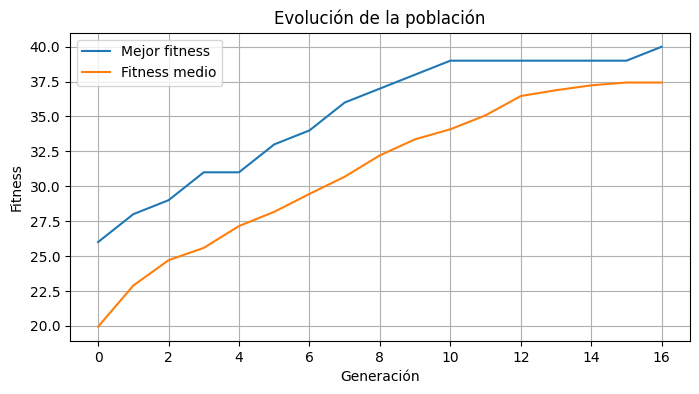

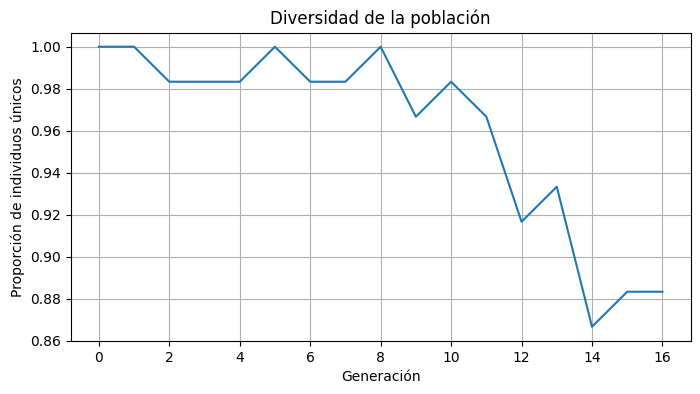

In [ ]:
generations = [h['generation'] for h in history]
best_values = [h['best'] for h in history]
mean_values = [h['mean'] for h in history]

plt.figure(figsize=(8, 4))
plt.plot(generations, best_values, label='Mejor fitness')
plt.plot(generations, mean_values, label='Fitness medio')
plt.xlabel('Generación')
plt.ylabel('Fitness')
plt.title('Evolución de la población')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(generations, [h['diversity'] for h in history])
plt.xlabel('Generación')
plt.ylabel('Proporción de individuos únicos')
plt.title('Diversidad de la población')
plt.grid(True)
plt.show()

## 6. Efecto de la mutación

Una tasa muy baja puede producir convergencia prematura. Una tasa muy alta destruye las estructuras que el cruce intenta conservar.

In [ ]:
rates = [0.0, 0.005, 0.025, 0.1, 0.5]
summary = []

for rate in rates:
    final_fitness = []
    generations_used = []
    for seed in range(20):
        best, hist = genetic_algorithm(
            chromosome_length=40,
            generations=120,
            mutation_rate=rate,
            seed=seed
        )
        final_fitness.append(fitness(best))
        generations_used.append(hist[-1]['generation'])
    summary.append((rate, np.mean(final_fitness), np.mean(generations_used)))

print('mutation_rate | fitness medio | generaciones medias')
for row in summary:
    print(f'{row[0]:>13.3f} | {row[1]:>13.2f} | {row[2]:>18.2f}')

mutation_rate | fitness medio | generaciones medias
        0.000 |         37.65 |             114.85
        0.005 |         40.00 |              19.90
        0.025 |         40.00 |              16.45
        0.100 |         38.45 |             117.00
        0.500 |         31.75 |             120.00


## Actividades

### Actividad 1 — Selección por ruleta

Implementa selección proporcional al fitness. Ten cuidado con poblaciones donde todos los individuos tengan fitness cero.

In [ ]:
# Actividad 1: selección proporcional al fitness.
def roulette_selection(population, rng):
    fitnesses = [fitness(individual) for individual in population]
    total_fitness = sum(fitnesses)

    # Si todos tienen fitness cero, ninguno tiene ventaja. Se elige al azar.
    if total_fitness == 0:
        return rng.choice(population).copy()

    selected_value = rng.uniform(0, total_fitness)
    accumulated = 0
    for individual, individual_fitness in zip(population, fitnesses):
        accumulated += individual_fitness
        if selected_value <= accumulated:
            return individual.copy()

    # Protección frente a pequeños errores de punto flotante.
    return population[-1].copy()


# Prueba normal y prueba especial con fitness total igual a cero.
roulette_rng = random.Random(SEED)
roulette_population = [
    [0, 0, 0, 0],
    [1, 0, 0, 0],
    [1, 1, 0, 0],
    [1, 1, 1, 1]
]
selection_counts = {as_string(ind): 0 for ind in roulette_population}
for _ in range(5000):
    selected = roulette_selection(roulette_population, roulette_rng)
    selection_counts[as_string(selected)] += 1

print('Frecuencia de selección en 5000 torneos de ruleta:')
for individual, count in selection_counts.items():
    print(individual, '- fitness:', fitness(list(map(int, individual))),
          '- selecciones:', count)

zero_population = [[0, 0, 0], [0, 0, 0], [0, 0, 0]]
print('Selección con fitness total cero:',
      as_string(roulette_selection(zero_population, roulette_rng)))
print('Conclusión: los individuos con mayor fitness tienen mayor probabilidad,')
print('pero la selección sigue siendo aleatoria y no garantiza elegir al mejor.')


Frecuencia de selección en 5000 torneos de ruleta:
0000 - fitness: 0 - selecciones: 0
1000 - fitness: 1 - selecciones: 719
1100 - fitness: 2 - selecciones: 1445
1111 - fitness: 4 - selecciones: 2836
Selección con fitness total cero: 000
Conclusión: los individuos con mayor fitness tienen mayor probabilidad,
pero la selección sigue siendo aleatoria y no garantiza elegir al mejor.


### Actividad 2 — Cruce uniforme

En cada posición, el hijo toma el gen del padre 1 o del padre 2 con igual probabilidad.

In [ ]:
# Actividad 2: cruce uniforme.
def uniform_crossover(parent1, parent2, crossover_rate, rng):
    if rng.random() >= crossover_rate:
        return parent1.copy(), parent2.copy()

    child1 = []
    child2 = []
    for gene1, gene2 in zip(parent1, parent2):
        if rng.random() < 0.5:
            child1.append(gene1)
            child2.append(gene2)
        else:
            child1.append(gene2)
            child2.append(gene1)
    return child1, child2


uniform_rng = random.Random(SEED)
parent1 = [1, 1, 1, 1, 0, 0, 0, 0]
parent2 = [0, 0, 0, 0, 1, 1, 1, 1]
child1, child2 = uniform_crossover(parent1, parent2, 1.0, uniform_rng)
print('Padre 1:', as_string(parent1))
print('Padre 2:', as_string(parent2))
print('Hijo 1 :', as_string(child1))
print('Hijo 2 :', as_string(child2))
print('Cada posición se heredó de uno de los padres con probabilidad de 50%.')


Padre 1: 11110000
Padre 2: 00001111
Hijo 1 : 00010110
Hijo 2 : 11101001
Cada posición se heredó de uno de los padres con probabilidad de 50%.


### Actividad 3 — Frase objetivo

Adapta el algoritmo para evolucionar una cadena hasta alcanzar una frase objetivo, por ejemplo `INTELIGENCIA ARTIFICIAL`.

Sugerencias:

- cromosoma: lista de caracteres;
- fitness: número de caracteres correctos en la posición correcta;
- alfabeto: letras, espacio y, opcionalmente, signos de puntuación.

Frase objetivo  : INTELIGENCIA ARTIFICIAL
Mejor individuo: INTELIGENCIA ARTIFICIAL
Fitness: 23 / 23
Generaciones: 13


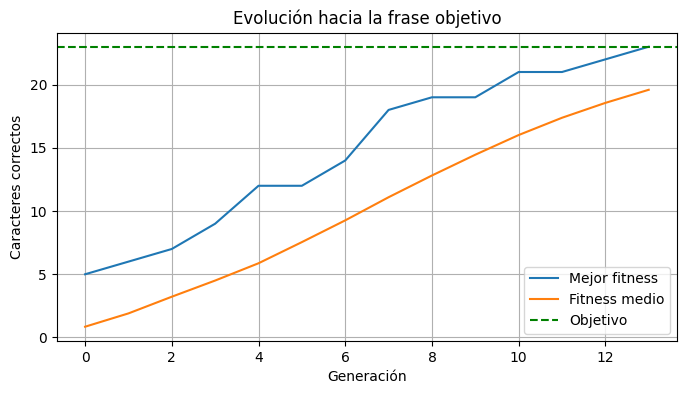

In [ ]:
# Actividad 3: evolución de una frase objetivo.
TARGET = 'INTELIGENCIA ARTIFICIAL'
ALPHABET = ' ABCDEFGHIJKLMNOPQRSTUVWXYZ'

def create_text_individual(length, rng):
    return [rng.choice(ALPHABET) for _ in range(length)]

def text_fitness(individual):
    return sum(gene == target_gene
               for gene, target_gene in zip(individual, TARGET))

def text_tournament_selection(population, tournament_size, rng):
    contestants = rng.sample(population, tournament_size)
    return max(contestants, key=text_fitness).copy()

def text_mutation(individual, mutation_rate, rng):
    child = individual.copy()
    for index in range(len(child)):
        if rng.random() < mutation_rate:
            child[index] = rng.choice(ALPHABET)
    return child

def phrase_genetic_algorithm(population_size=300, generations=1000,
                             crossover_rate=0.9, mutation_rate=0.03,
                             tournament_size=5, seed=0):
    rng = random.Random(seed)
    population = [create_text_individual(len(TARGET), rng)
                  for _ in range(population_size)]
    history = []

    for generation in range(generations + 1):
        best = max(population, key=text_fitness).copy()
        history.append({
            'generation': generation,
            'best': text_fitness(best),
            'mean': float(np.mean([text_fitness(ind) for ind in population])),
            'best_individual': best
        })
        if text_fitness(best) == len(TARGET):
            break

        new_population = [best]  # Elitismo
        while len(new_population) < population_size:
            parent1 = text_tournament_selection(population, tournament_size, rng)
            parent2 = text_tournament_selection(population, tournament_size, rng)
            child1, child2 = uniform_crossover(
                parent1, parent2, crossover_rate, rng
            )
            new_population.extend([
                text_mutation(child1, mutation_rate, rng),
                text_mutation(child2, mutation_rate, rng)
            ])
        population = new_population[:population_size]

    return history[-1]['best_individual'], history


best_phrase, phrase_history = phrase_genetic_algorithm(seed=SEED)
print('Frase objetivo  :', TARGET)
print('Mejor individuo:', ''.join(best_phrase))
print('Fitness:', text_fitness(best_phrase), '/', len(TARGET))
print('Generaciones:', phrase_history[-1]['generation'])

phrase_generations = [record['generation'] for record in phrase_history]
plt.figure(figsize=(8, 4))
plt.plot(phrase_generations, [record['best'] for record in phrase_history],
         label='Mejor fitness')
plt.plot(phrase_generations, [record['mean'] for record in phrase_history],
         label='Fitness medio')
plt.axhline(len(TARGET), linestyle='--', color='green', label='Objetivo')
plt.xlabel('Generación'); plt.ylabel('Caracteres correctos')
plt.title('Evolución hacia la frase objetivo')
plt.legend(); plt.grid(True); plt.show()


### Actividad 4 — Sin elitismo

Ejecuta el algoritmo con y sin elitismo. ¿Puede disminuir el mejor fitness de una generación a la siguiente? Explica el resultado.

Elitismo | fitness final medio | corridas con disminución | éxito
True     |               40.00 |                        0 | 100.0%
False    |               40.00 |                       15 | 100.0%


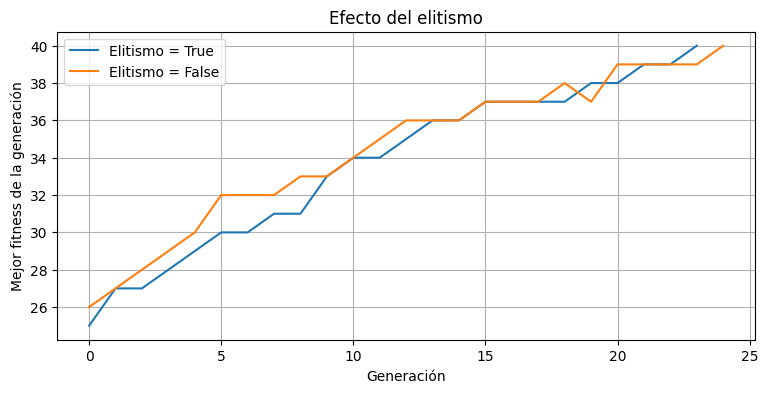

Conclusión: con elitismo, el mejor individuo se copia directamente y el
mejor fitness no puede disminuir. Sin elitismo sí puede disminuir porque
los mejores individuos pueden no ser seleccionados o pueden alterarse por
el cruce y la mutación antes de formar la generación siguiente.


In [ ]:
# Actividad 4: comparación con y sin elitismo.
elitism_results = []
for use_elitism in [True, False]:
    decreases_per_run = []
    final_fitnesses = []
    success_count = 0
    example_history = None

    for seed in range(30):
        best_individual, run_history = genetic_algorithm(
            chromosome_length=40,
            population_size=30,
            generations=80,
            mutation_rate=0.01,
            elitism=use_elitism,
            seed=seed
        )
        best_by_generation = [record['best'] for record in run_history]
        decreases = sum(current < previous for previous, current in
                        zip(best_by_generation, best_by_generation[1:]))
        decreases_per_run.append(decreases)
        final_fitnesses.append(fitness(best_individual))
        success_count += fitness(best_individual) == 40
        if example_history is None or decreases > 0:
            example_history = run_history

    elitism_results.append({
        'elitism': use_elitism,
        'mean_final': float(np.mean(final_fitnesses)),
        'runs_with_decrease': sum(value > 0 for value in decreases_per_run),
        'mean_decreases': float(np.mean(decreases_per_run)),
        'success_percentage': 100 * success_count / 30,
        'example_history': example_history
    })

print('Elitismo | fitness final medio | corridas con disminución | éxito')
for result in elitism_results:
    print(f"{str(result['elitism']):8} | {result['mean_final']:19.2f} | "
          f"{result['runs_with_decrease']:24d} | {result['success_percentage']:.1f}%")

plt.figure(figsize=(9, 4))
for result in elitism_results:
    example = result['example_history']
    plt.plot([record['generation'] for record in example],
             [record['best'] for record in example],
             label=f"Elitismo = {result['elitism']}")
plt.xlabel('Generación'); plt.ylabel('Mejor fitness de la generación')
plt.title('Efecto del elitismo')
plt.legend(); plt.grid(True); plt.show()

print('Conclusión: con elitismo, el mejor individuo se copia directamente y el')
print('mejor fitness no puede disminuir. Sin elitismo sí puede disminuir porque')
print('los mejores individuos pueden no ser seleccionados o pueden alterarse por')
print('el cruce y la mutación antes de formar la generación siguiente.')


## Preguntas de cierre

1. ¿Qué papel cumple la población que no existe en Hill Climbing?

La población mantiene varias soluciones al mismo tiempo. Esto permite explorar diferentes regiones del espacio de búsqueda, combinar información de distintos individuos y conservar diversidad. Hill Climbing normalmente trabaja con una sola solución y sus vecinos.

2. ¿Por qué el cruce no garantiza hijos mejores que sus padres?

 Porque el cruce mezcla fragmentos sin saber cuáles combinaciones producen un fitness mayor. Puede juntar características útiles, pero también separar o destruir combinaciones que funcionaban bien en los padres.

3. ¿Qué significa convergencia prematura?

 Significa que la población pierde diversidad muy pronto y se concentra en soluciones parecidas antes de encontrar el óptimo global. En ese caso, el algoritmo puede quedar alrededor de una solución subóptima.

4. ¿Qué parámetros controlan la exploración?

Principalmente la tasa de mutación, el tamaño de la población, la tasa y el tipo de cruce, el tamaño del torneo y el elitismo. Una mutación mayor y una población más grande suelen aumentar la exploración; torneos grandes y un elitismo fuerte aumentan la explotación de las mejores soluciones conocidas.
